## **X2**: TT - Class Structure of the Kernels
* October 4°, 2026 · rerun on October 5°, 2026 with C5 = Y and ZZ terms (D-031)
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Notebook 5b showed that the fidelity kernels of C4 and C5 are concentrated: two distinct
lesions have a median similarity of about 0.002 with C4 and 0.00003 with C5, against 0.6 for
the classical RBF kernel (H-031, D-031). That figure does not use the labels, so it says how similar *any* two lesions are,
not whether lesions of the **same class** are more similar than lesions of **different
classes**. This notebook adds that distinction.

The kernels are read from Module 5 as they are, on the same 200 training lesions per subset
(D-028). Module 5 never uses the labels; they enter here for the first time. Each pair of
distinct lesions is counted once (upper triangle of the matrix) and falls in one of three
groups: benign–benign (B–B), malignant–malignant (M–M) or benign–malignant (B–M).

Two outputs:

1. The distribution of the kernel value in each group, at the preregistered scale $c = 1$.
2. A single number per kernel, the **pair AUC**: the probability that a randomly chosen
   same-class pair is more similar than a randomly chosen different-class pair. It is 0.5
   when the kernel ignores the class and 1 when every same-class pair is more similar than
   every different-class pair. Being based on ranks, it does not care that the quantum values
   are hundreds or thousands of times smaller than the classical ones, so the three kernels
   are comparable.

Pairs share lesions, so they are not independent and a textbook test would overstate the
evidence. The reference is therefore a **permutation test**: the labels are shuffled 1,000
times, keeping the class counts, and the pair AUC is recomputed each time.

The pair AUC is close in spirit to the kernel-target alignment of Module 6, which also
contrasts same-class and different-class similarities, $\langle K, yy^\top\rangle =
\sum_{\text{same}} K_{ij} - \sum_{\text{different}} K_{ij}$. It is exploratory and does not
replace the metrics of Module 6. Result recorded as H-036.

#### **1° Setup**

**a.** Import the necessary libraries and load the Module 5 kernels

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import rankdata

SEED = 42
N_PERM = 1000
FINDINGS = ["mass", "calcification"]
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]

ROOT = Path("/Users/alexander_san/TT")
M5_DIR = ROOT / "Data/processed/m5"
RESULTS_DIR = ROOT / "Code/results"
FIG_DIR = ROOT / "Docs/Figures"

kernels, labels = {}, {}
for ft in FINDINGS:
    z = np.load(M5_DIR / f"kernels_{ft}.npz", allow_pickle=True)
    kernels[ft] = {k: z[k] for k in z.files if k.startswith("K_")}
    labels[ft] = z["label"].astype(int)
    assert np.allclose(kernels[ft]["K_Q_C4"], kernels[ft]["K_Q_C4_c1.0"])
    assert np.allclose(kernels[ft]["K_Q_C5"], kernels[ft]["K_Q_C5_c1.0"])

print(f"numpy {np.__version__} | scipy {scipy.__version__} | pandas {pd.__version__}")
for ft in FINDINGS:
    y = labels[ft]
    n = len(y)
    print(f"{ft:13s}: {n} lesions ({int(y.sum())} malignant, {int((y == 0).sum())} benign); "
          f"{n * (n - 1) // 2} distinct pairs")

numpy 2.2.6 | scipy 1.15.3 | pandas 2.3.3
mass         : 200 lesions (97 malignant, 103 benign); 19900 distinct pairs
calcification: 200 lesions (70 malignant, 130 benign); 19900 distinct pairs


**b.** Split the distinct pairs by class

In [2]:
GROUPS = {"B–B": (0, 0), "M–M": (1, 1)}


def pair_groups(y):
    i, j = np.triu_indices(len(y), 1)
    same = y[i] == y[j]
    groups = {name: same & (y[i] == a) for name, (a, _) in GROUPS.items()}
    groups["B–M"] = ~same
    return (i, j), same, groups


for ft in FINDINGS:
    _, same, groups = pair_groups(labels[ft])
    print(f"{ft:13s}: " + ", ".join(f"{g} {int(m.sum())}" for g, m in groups.items())
          + f"  (same class {int(same.sum())}, different class {int((~same).sum())})")

mass         : B–B 5253, M–M 4656, B–M 9991  (same class 9909, different class 9991)
calcification: B–B 8385, M–M 2415, B–M 9100  (same class 10800, different class 9100)


#### **2° Distribution of the kernel value by pair type**

Each panel shows the density of the kernel value for the three pair types, at $c = 1$.
Each curve shows the fraction of the pairs of its group that falls in each bin, not raw counts,
because the groups have different sizes; the bins are equal on the logarithmic axis. Each pair
appears once.
If a kernel carried class information, the B–B and M–M curves would sit to the right of the
B–M curve: same-class lesions would look more alike.

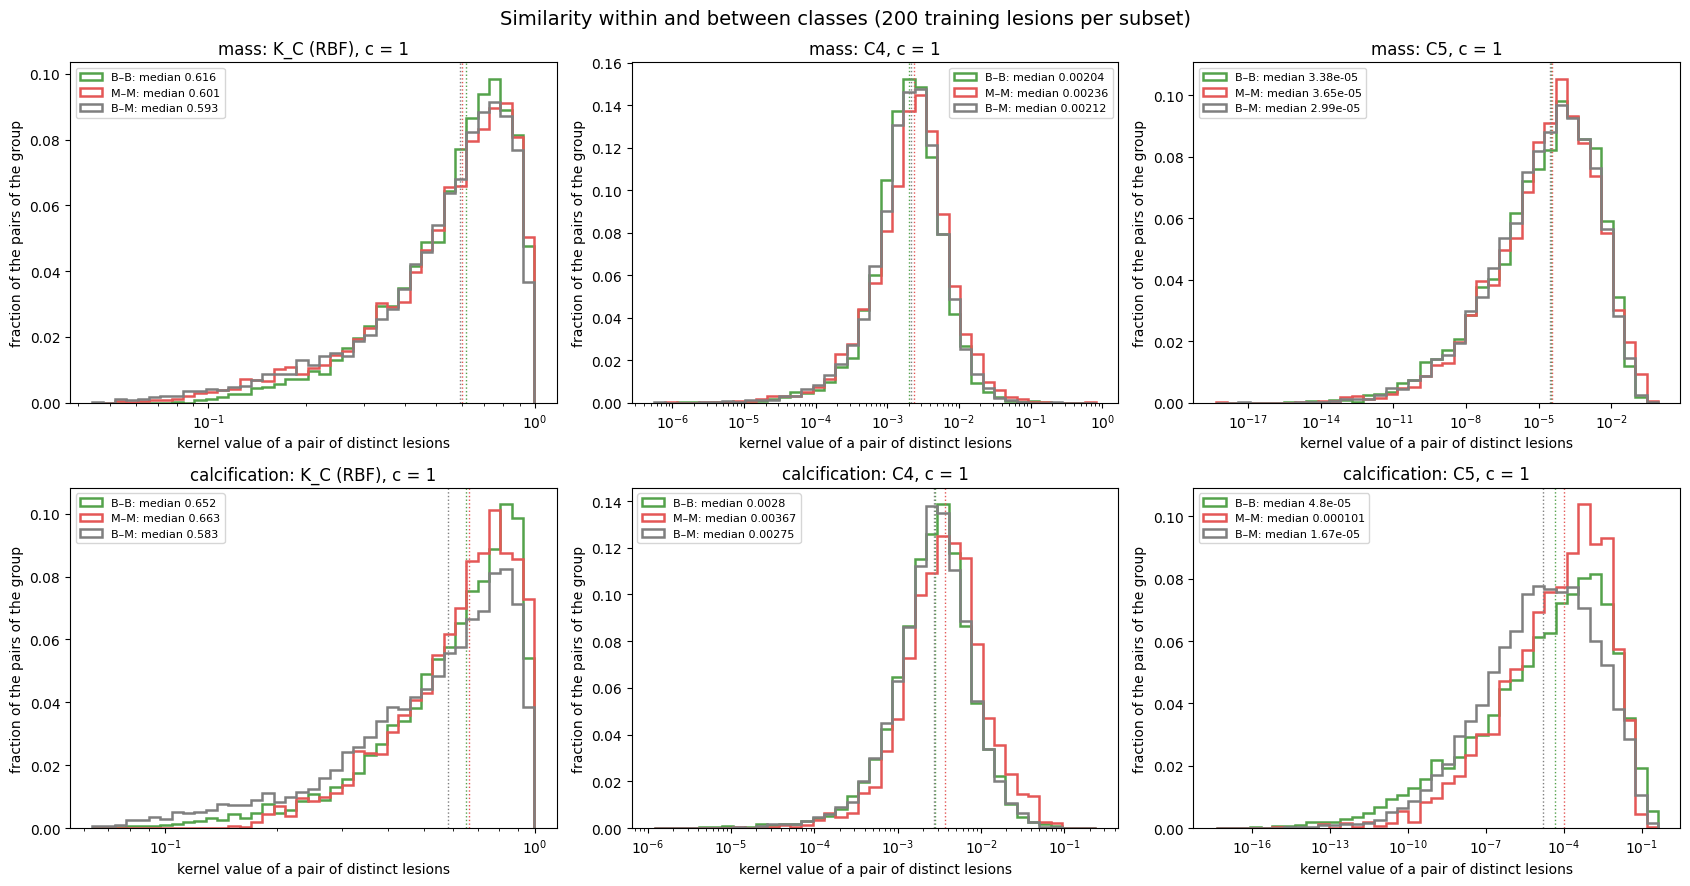

group                       B–B     M–M     B–M
finding_type  kernel                           
mass          C4         0.0020  0.0024  0.0021
              C5         0.0000  0.0000  0.0000
              K_C (RBF)  0.6158  0.6011  0.5926
calcification C4         0.0028  0.0037  0.0027
              C5         0.0000  0.0001  0.0000
              K_C (RBF)  0.6515  0.6631  0.5828


In [3]:
KERNELS_C1 = {"K_C (RBF)": "K_C", "C4": "K_Q_C4", "C5": "K_Q_C5"}
group_colors = {"B–B": "#54A24B", "M–M": "#E45756", "B–M": "#7F7F7F"}

median_rows = []
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, ft in enumerate(FINDINGS):
    (i, j), same, groups = pair_groups(labels[ft])
    for col, (title, key) in enumerate(KERNELS_C1.items()):
        ax = axes[row, col]
        v = kernels[ft][key][i, j]
        pos = v[v > 0]
        bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40)
        for g, mask in groups.items():
            vals = v[mask & (v > 0)]
            med = float(np.median(v[mask]))
            median_rows.append(dict(finding_type=ft, kernel=title, group=g, n_pairs=int(mask.sum()), median=med))
            ax.hist(vals, bins=bins, weights=np.full(len(vals), 1 / mask.sum()), histtype="step", lw=1.8,
                    color=group_colors[g], label=f"{g}: median {med:.3g}")
            ax.axvline(med, color=group_colors[g], ls=":", lw=1)
        ax.set_xscale("log")
        ax.set_title(f"{ft}: {title}, c = 1")
        ax.set_xlabel("kernel value of a pair of distinct lesions")
        ax.set_ylabel("fraction of the pairs of the group")
        ax.legend(fontsize=8)
fig.suptitle("Similarity within and between classes (200 training lesions per subset)", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "X2_kernel_pairs_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

medians = pd.DataFrame(median_rows)
print(medians.pivot_table(index=["finding_type", "kernel"], columns="group", values="median")
      .reindex(FINDINGS, level=0)[["B–B", "M–M", "B–M"]].round(4).to_string())

#### **3° Pair AUC and permutation test**

**a.** For the classical kernel and for C4 and C5 at every scale $c$ of the sweep (D-029)

The ranks of the kernel values are computed once per kernel; each permutation only changes
which pairs count as same-class. The same 1,000 permutations are used for every kernel of a
subset. The one-sided $p$ value is $(1 + \#\{\text{null} \ge \text{observed}\}) / (1 + 1000)$,
so 0.001 is the smallest value it can take. Many kernels are tested, so the $p$ values are
indicative, not a formal multiple-comparison analysis.

In [4]:
def pair_auc(ranks, same):
    n1, n0 = int(same.sum()), int((~same).sum())
    return (ranks[same].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


auc_rows = []
for ft in FINDINGS:
    y = labels[ft]
    (i, j), same, _ = pair_groups(y)
    rng = np.random.default_rng(SEED)
    perm_same = [(lambda p: p[i] == p[j])(rng.permutation(y)) for _ in range(N_PERM)]
    keys = [("K_C (RBF)", None, "K_C")] + [(f"C{q}", c, f"K_Q_C{q}_c{c}") for q in (4, 5) for c in SCALES]
    for name, c, key in keys:
        ranks = rankdata(kernels[ft][key][i, j])
        observed = pair_auc(ranks, same)
        null = np.array([pair_auc(ranks, s) for s in perm_same])
        auc_rows.append(dict(finding_type=ft, kernel=name, c=c, pair_auc=observed,
                             null_mean=null.mean(), null_std=null.std(),
                             null_p025=np.percentile(null, 2.5), null_p975=np.percentile(null, 97.5),
                             p_value=(1 + int((null >= observed).sum())) / (1 + N_PERM)))

auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(RESULTS_DIR / "X2_auc_pares.csv", index=False)
show = auc_df.assign(c=auc_df.c.map(lambda v: "—" if pd.isna(v) else f"{v:g}"))
print(show[["finding_type", "kernel", "c", "pair_auc", "null_mean", "null_std", "p_value"]]
      .round(4).to_string(index=False))

 finding_type    kernel    c  pair_auc  null_mean  null_std  p_value
         mass K_C (RBF)    —    0.5229     0.4999    0.0037   0.0020
         mass        C4    1    0.5103     0.5000    0.0037   0.0120
         mass        C4  0.5    0.5126     0.5000    0.0038   0.0070
         mass        C4  0.2    0.5221     0.4999    0.0036   0.0010
         mass        C4  0.1    0.5068     0.4999    0.0036   0.0470
         mass        C4 0.05    0.5211     0.4999    0.0036   0.0010
         mass        C4 0.02    0.5221     0.4999    0.0037   0.0020
         mass        C5    1    0.5083     0.5000    0.0041   0.0470
         mass        C5  0.5    0.5012     0.5000    0.0030   0.2907
         mass        C5  0.2    0.5112     0.5000    0.0039   0.0140
         mass        C5  0.1    0.5106     0.5000    0.0033   0.0090
         mass        C5 0.05    0.5217     0.4999    0.0036   0.0010
         mass        C5 0.02    0.5224     0.4999    0.0037   0.0020
calcification K_C (RBF)    —    0.

**b.** Pair AUC against the angle scale. Both panels share the vertical axis, so that differences of 0.01 are not magnified The gray band is the envelope of the central 95 % of the permutation AUCs over all the kernels of the subset, so it is conservative; each $p$ value in the table above uses the null of its own kernel.

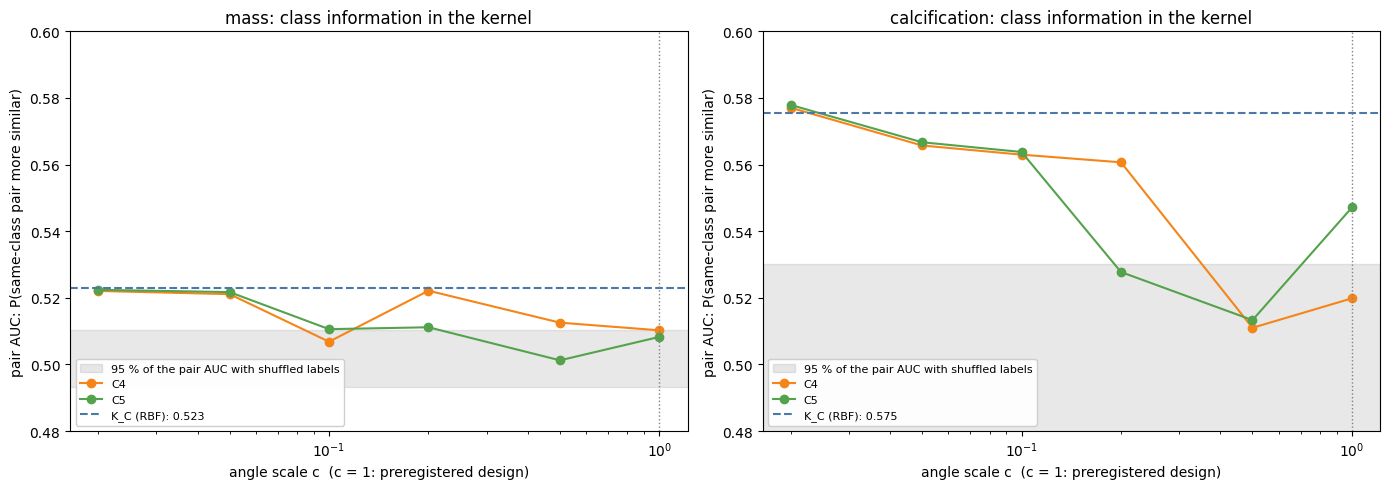

In [5]:
colors = {"C4": "#F58518", "C5": "#54A24B"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ft in zip(axes, FINDINGS):
    a = auc_df[auc_df.finding_type == ft]
    ax.axhspan(a.null_p025.min(), a.null_p975.max(), color="gray", alpha=0.18,
               label="95 % of the pair AUC with shuffled labels")
    for q in ("C4", "C5"):
        s = a[a.kernel == q].sort_values("c")
        ax.plot(s.c, s.pair_auc, marker="o", color=colors[q], label=q)
    kc = a[a.kernel == "K_C (RBF)"].pair_auc.iloc[0]
    ax.axhline(kc, color="#4C78A8", ls="--", label=f"K_C (RBF): {kc:.3f}")
    ax.axvline(1, color="gray", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("angle scale c  (c = 1: preregistered design)")
    ax.set_ylabel("pair AUC: P(same-class pair more similar)")
    ax.set_title(f"{ft}: class information in the kernel")
    ax.set_ylim(0.48, 0.60)
    ax.legend(fontsize=8, loc="lower left", framealpha=0.95)
plt.tight_layout()
plt.savefig(FIG_DIR / "X2_pair_auc_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

#### **4° Consequence**

**1. The classical kernel does see the classes, modestly.** Same-class pairs are more similar
than different-class pairs: pair AUC 0.523 in masses and 0.575 in calcifications ($p \le 0.002$).
In calcifications the effect comes mostly from benign–malignant pairs being less similar
(median 0.583, against 0.652 for B–B and 0.663 for M–M). Masses are hard for every kernel,
consistent with the moderate effect sizes of Module 3 (H-023).

**2. At the preregistered scale, the quantum kernels keep only part of that information.**
In masses the pair AUC is 0.510 (C4) and 0.508 (C5): at most 0.01 above chance ($p = 0.012$
and $0.047$). In calcifications it is 0.520 (C4) and 0.547 (C5). C4 keeps about a quarter of
the margin of the RBF over chance (0.020 against 0.075) and C5 about 60 % (0.047). In the
histograms of C4 the three pair types overlap almost completely; in those of C5 for
calcifications, the benign–malignant pairs sit visibly to the left.

**3. Shrinking the angles recovers it, but only up to the classical level.** As $c$ decreases
the pair AUC rises, not monotonically, and at $c = 0.02$ both maps match the RBF (0.522 against
0.523 in masses, 0.577 and 0.578 against 0.575 in calcifications). At that scale the quantum
kernel is practically the kernel of a map without the product term $x_i x_j$ (H-031). The class
information recovered is the one a classical kernel already sees, not new information from
feature interactions.

**4. C4 against C5 (D-031).** C5 now has a Y first-order term, which rotates each qubit off the
equator, against the Z term of C4. In masses the two are indistinguishable at $c = 1$ (the
permutation standard deviation is 0.004). In calcifications C5 is above C4 by 0.027, about
three to four permutation standard deviations; many kernels are tested, so this is an
indication, not a formal test. With the original C5, a ZZ-only map (H-034), the values were
0.505 and 0.515, indistinguishable from C4.

**5. Values no device could measure.** The C5 kernel is far more concentrated: 26 % (masses)
and 28 % (calcifications) of its pairs are below $10^{-6}$, and about 2–3 % below $10^{-10}$,
close to numerical precision. On hardware a kernel entry is the probability of the all-zeros
outcome, so even seeing it once takes about $1/K$ shots: $10^6$ for $K = 10^{-6}$ and $10^{10}$
for $K = 10^{-10}$. The ranks among those values exist only in exact simulation (OE-6).
The class signal does not come from those values: restricted to the pairs at or above
$10^{-6}$, the pair AUC of C5 is 0.510 in masses and 0.570 in calcifications.

**Consequences.**

- With this pairwise measure there is no sign that the quantum encoding captures class
  structure the classical kernel misses; at the preregistered design both maps capture less. This
  anticipates the kernel-target alignment and the geometric difference of Module 6, which
  remain the formal metrics.
- The pair AUC is a global measure over all pairs. Values of 0.52–0.58 are normal when the
  classes are heterogeneous, and they do not bound the AUC of a classifier, which can exploit
  local structure.
- The conclusion holds in both subsets, analysed separately (D-005).
- Q-012 was closed by D-031 (C5 = Y and ZZ). The Y term changes the result only in
  calcifications, and even there C5 stays below the classical kernel.

In [6]:
print("=" * 76)
print("X2 - CLASS STRUCTURE OF THE KERNELS - SUMMARY")
print("=" * 76)
for ft in FINDINGS:
    a = auc_df[auc_df.finding_type == ft].set_index(["kernel", "c"], drop=False)
    kc = a[a.kernel == "K_C (RBF)"].iloc[0]
    print(f"  {ft}  (pair AUC; chance = 0.5, permutation std ~{a.null_std.mean():.3f})")
    print(f"    K_C (RBF)      : {kc.pair_auc:.3f}  p = {kc.p_value:.3f}")
    for q in ("C4", "C5"):
        r1, r02 = a.loc[(q, 1.0)], a.loc[(q, 0.02)]
        print(f"    {q} at c = 1    : {r1.pair_auc:.3f}  p = {r1.p_value:.3f}   |  at c = 0.02: {r02.pair_auc:.3f}")
print("  200 training lesions per subset (D-028); each pair counted once. Recorded as H-036.")
print("=" * 76)

X2 - CLASS STRUCTURE OF THE KERNELS - SUMMARY
  mass  (pair AUC; chance = 0.5, permutation std ~0.004)
    K_C (RBF)      : 0.523  p = 0.002
    C4 at c = 1    : 0.510  p = 0.012   |  at c = 0.02: 0.522
    C5 at c = 1    : 0.508  p = 0.047   |  at c = 0.02: 0.522
  calcification  (pair AUC; chance = 0.5, permutation std ~0.008)
    K_C (RBF)      : 0.575  p = 0.001
    C4 at c = 1    : 0.520  p = 0.021   |  at c = 0.02: 0.577
    C5 at c = 1    : 0.547  p = 0.001   |  at c = 0.02: 0.578
  200 training lesions per subset (D-028); each pair counted once. Recorded as H-036.
